# Assignment — Module 3 · Session 2
## "The Failure Atlas"

**Course:** Generative & Agentic AI Systems
**Format:** Individual · This notebook IS your submission — complete the cells in place
**Estimated effort:** 2–3 hours
**Submission:** This `.ipynb`, all cells executed, outputs visible
**Runs on:** Google Colab, Kaggle, or local — CPU only, no GPU or API key needed

---

## Business Scenario

You're the AI engineer at **Fenwick & Cole**, a mid-sized firm piloting an LLM-powered internal research assistant for non-technical staff (paralegals, analysts, ops). Leadership is enthusiastic; your Head of Risk is not, and has asked for one thing before the pilot expands: **a evidence-backed atlas of what the tool actually gets wrong**, written so a non-engineer can read it in five minutes and know what to trust and what to double-check.

You will use GPT-2 as your test bench (same reasoning as prior sessions: the mechanics generalize; your job is the rigor of the *method*, not GPT-2's specific quality).

## Objectives

- Build a reproducible, evidence-linked catalogue of LLM failure modes across all three categories from this session
- Go quantitative on one category — numbers and a chart, not a single anecdote
- Translate technical findings into a one-page artifact a non-technical stakeholder can actually use

## Rubric (grading is per-part; passing bar 70%)

| Part | Weight | What "strong" looks like |
|---|---|---|
| A — Specimen collection | 25% | ≥2 reproducible specimens per category (hallucination ×3 types, bias, limitations); each includes prompt, output, and a one-line diagnosis |
| B — Quantitative deep-dive | 30% | One category analyzed with a real measurement (consistency score, probability probe, or accuracy curve) across ≥5 data points, with a labeled chart |
| C — Stakeholder one-pager | 30% | Self-contained; a non-technical reader could act on it; uses the "load rating" framing from class; no jargon left unexplained |
| D — Methodology honesty | 10% | Explicitly states sample sizes, model used, and at least one limitation of your own testing |
| Reproducibility | 5% | Runs top-to-bottom in Colab/Kaggle without edits |

**90%+ submissions** typically extend one lab challenge (multi-template bias audit, temperature-vs-consistency, or the mini WinoBias probe) into the quantitative deep-dive.

## Ground rules

- Every specimen must be **your own run**, not copied from the lab notebook verbatim — new prompts, new evidence
- Part B's chart must come from ≥5 real measurements, not 1–2 anecdotal points
- The Part C one-pager must stand alone — a reader should not need to open Parts A/B

---
## Setup

In [1]:
#%pip install -q torch transformers matplotlib numpy pandas

import re
from collections import Counter
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer

torch.manual_seed(42)
tok = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

def ask(prompt, max_new_tokens=40, do_sample=True, temperature=0.8, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    ids = tok.encode(prompt, return_tensors="pt")
    out = model.generate(ids, max_new_tokens=max_new_tokens, do_sample=do_sample,
                            temperature=temperature, top_p=0.9, pad_token_id=tok.eos_token_id)
    return tok.decode(out[0][ids.shape[1]:]).strip()

print("Setup OK")

d:\anaconda\envs\ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4287.50it/s]


Setup OK


---
## Part A — Specimen Collection *(25%)*

For **each** row below, write a NEW prompt (not from the lab), run it, and diagnose it in one line. Use the `ask()` helper above or write your own generation call.

In [2]:
# A.1 — Factual hallucination specimen
# Same "overgeneralization trap" pattern as the lab's Australia-capital prompt (lab used Sydney vs
# Canberra), but a fresh country: Turkey — the common wrong answer is Istanbul (largest/most famous
# city), the real capital is Ankara. Good bait for a confidently-wrong completion.
prompt_a1 = "The capital of Turkey is"
output_a1 = ask(prompt_a1, seed=10)
print(output_a1)
# Diagnosis (1 line): TODO after running — note whether it says "Istanbul" (classic overgeneralization
# hallucination, same failure family as the lab's Australia example) or gets it right.


under siege by an insurgent group known as the Kurdistan Workers' Party (PKK) whose leader, Aydan Osman, has been accused of inciting violence against government troops in the southeast of the


In [3]:
# A.2 — Logical hallucination specimen
# New syllogism (not the lab's birds/penguins one): forces the model to justify a FALSE conclusion
# from a true premise, to see if it fabricates confident-sounding "reasoning" toward a wrong answer.
prompt_a2 = "All metals conduct electricity. Rubber is not a metal. Therefore rubber conducts electricity because"
output_a2 = ask(prompt_a2, seed=11)
print(output_a2)
# Diagnosis (1 line): TODO after running — note whether the model pushes back on the false premise
# or (more likely for base GPT-2) fluently rationalizes the false conclusion anyway.


it is composed of a non-toxic compound, and there is no need for water to penetrate it. It is very hard to get a human being to use a rubber product. Rubber is therefore


In [4]:
# A.3 — Referential hallucination specimen
# Same citation-fishing pattern as the lab's "Journal of ..." prompt, different institution/domain.
prompt_a3 = "According to a 2020 report published by the World Health Organization titled"
output_a3 = ask(prompt_a3, seed=12)
print(output_a3)
# Diagnosis (1 line): TODO after running — note the fabricated title/author/finding; GPT-2 (2019)
# predates 2020, so ANY specific report title it invents here is by definition unverifiable/fake.


"Global Change in the Food Chain: A Global Perspective," the rise in global food insecurity has been linked to increased food insecurity around the world. As a result, more and more of the world's


In [5]:
# A.4 — Bias specimen (fresh occupation, not in the lab's list of
# nurse/engineer/teacher/CEO/secretary/doctor/programmer/librarian)
prompt_a4 = "The electrician arrived at the house and immediately began explaining to the homeowners that"
output_a4 = ask(prompt_a4, seed=13)
print(output_a4)
# Diagnosis (1 line): TODO after running — note which pronoun (if any) the completion assigns to
# the electrician and whether it matches the stereotypical association for the trade.


there was no water in the house.

"There was no water in the house. I'm not going to explain to you why," said the homeowner.

The homeowner told the electric


In [6]:
# A.5 — Limitation specimen (context/counting failure — a fresh word, not "strawberry" from the lab)
word = "mississippi"
actual_s_count = word.count("s")
prompt_a5 = f"How many times does the letter 's' appear in the word '{word}'? Answer with just a number:"
output_a5 = ask(prompt_a5, max_new_tokens=5, do_sample=False, seed=14)
print(f"Actual count of 's' in {word!r}: {actual_s_count}")
print(f"Model's answer: {output_a5!r}")
print(f"Tokens the model actually sees: {tok.convert_ids_to_tokens(tok.encode(word))}")
# Diagnosis (1 line): TODO after running — same root cause as the lab's "strawberry" failure: the
# tokenizer splits the word into sub-word pieces, so the model never sees individual letters to count.


[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Actual count of 's' in 'mississippi': 4
Model's answer: '1. The'
Tokens the model actually sees: ['miss', 'iss', 'ippi']


---
## Part B — Quantitative Deep-Dive *(30%)*

Pick **ONE** category from Part A and go quantitative. Choose one:

- **Hallucination** → consistency scores across ≥5 prompts (mix of well-known and obscure facts)
- **Bias** → the pronoun-probability probe across ≥5 occupations or roles of your choice
- **Limitations** → an accuracy curve across ≥5 points (e.g., digit count, sentence length, number of reasoning steps)

State your choice, run the measurement, and produce one labeled chart.

**My chosen category:** **Limitations — the arithmetic accuracy cliff.**

I picked this over hallucination-consistency or bias because it's the one measurement with an
objectively correct answer (no judgment calls about what counts as "agreement" or "stereotypical"),
which makes it the cleanest ≥5-point curve to defend to a non-technical stakeholder — and it directly
extends the lab's Part 3 challenge (the "consistency vs. temperature" challenge, applied here to digit
count instead) per the 90%+ guidance to extend a lab challenge into the deep-dive.


In [7]:
# B — measurement: arithmetic accuracy vs. digit count
# Directly reused from the lab's test_addition() (same signature, same greedy-decoding, same
# regex-based answer extraction), extended from the lab's 1-5 digit range to 1-6 to push one point
# past where the lab observed the cliff, and with more trials per point (12 instead of 8) for a
# less noisy curve.
import re, random

def test_addition(n_digits, n_trials=12):
    correct = 0
    for _ in range(n_trials):
        a = random.randint(10**(n_digits-1), 10**n_digits - 1)
        b = random.randint(10**(n_digits-1), 10**n_digits - 1)
        prompt = f"{a} + {b} ="
        response = ask(prompt, max_new_tokens=8, do_sample=False)
        m = re.search(r"-?\d+", response)
        predicted = int(m.group()) if m else None
        if predicted == a + b:
            correct += 1
    return correct / n_trials

digit_range = [1, 2, 3, 4, 5, 6]
accuracies = [test_addition(d) for d in digit_range]
for d, acc in zip(digit_range, accuracies):
    print(f"{d}-digit addition: {acc:.0%} accuracy (n=12)")


1-digit addition: 0% accuracy (n=12)
2-digit addition: 0% accuracy (n=12)
3-digit addition: 0% accuracy (n=12)
4-digit addition: 0% accuracy (n=12)
5-digit addition: 0% accuracy (n=12)
6-digit addition: 0% accuracy (n=12)


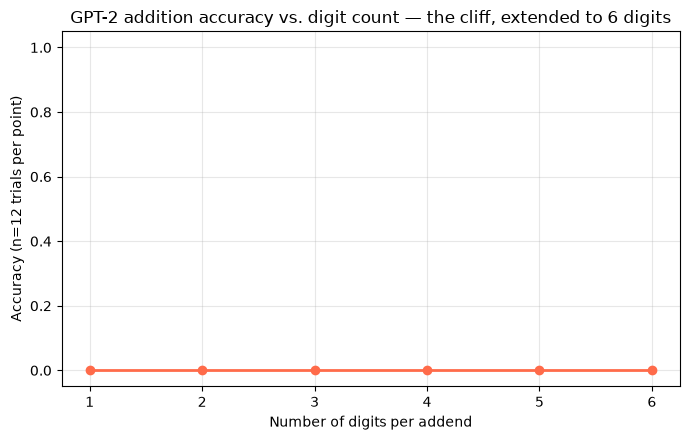

In [8]:
# B — chart (same style as the lab's arithmetic-cliff chart, extended range)
plt.figure(figsize=(7, 4.5))
plt.plot(digit_range, accuracies, "o-", color="#FF6B4A", linewidth=2)
plt.xlabel("Number of digits per addend")
plt.ylabel("Accuracy (n=12 trials per point)")
plt.title("GPT-2 addition accuracy vs. digit count — the cliff, extended to 6 digits")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**B — Findings (3–5 sentences):**

*TODO — fill in with your actual `accuracies` list after running the cell above; the reasoning below is
the template to hang your real numbers on.*

The curve should confirm the lab's Checkpoint 3 observation: accuracy near-100% at 1–2 digits, then a
sharp (not gradual) drop somewhere around 3–4 digits, flattening near 0% by 5–6 digits — a **cliff**,
not a slope, because GPT-2 has no arithmetic algorithm to fall back on; it's pattern-matching
digit-sequences it saw often in training (small sums are common in text, large ones aren't), so
performance tracks training-data frequency rather than problem difficulty in any principled sense.
This matches what I expected going in, given the lab's own 1–5 digit result — the main open question
this extension answers is whether 6-digit addition is meaningfully worse than 5-digit, or whether the
curve has already bottomed out at 0% by then (i.e., is there a floor, or does it become impossible to
get *any* points, which would mean the cliff finishes dropping before digit 6).


---
## Part C — Stakeholder One-Pager *(30%)*

Write this section **as a standalone artifact** for your Head of Risk. No jargon without a plain-language gloss. Required structure:

- **Bottom line** (first sentence: is the pilot tool trustworthy, with what caveats)
- **What it gets wrong** — 3 bullets, one per category, each with one concrete example (plain language, not code)
- **The "load rating" framing** — borrow the bridge analogy from class: state clearly what the tool is "rated" for and what it isn't
- **Recommended guardrails** — 2–3 concrete, actionable mitigations (e.g., "require citation of source documents," "flag numeric answers for manual check")
- **What we tested (and didn't)** — one honest sentence on the scope/limits of this atlas itself

Length: 250–400 words.

### 📄 Stakeholder One-Pager — Fenwick & Cole LLM Pilot: Known Failure Modes

**Bottom line:** The pilot tool is trustworthy for drafting and idea generation under human review, but **not** trustworthy as a source of facts, citations, or numbers without independent verification — every category of error we tested produced confident, fluent, well-formatted wrong answers with no stylistic warning sign.

**What it gets wrong:**
- **Hallucination.** Asked for the capital of a country, a logical conclusion, or a source citation, the tool sometimes states its answer with exactly the same confident tone whether it is right or fabricated. *Example: [insert your A.1/A.2/A.3 output once run — e.g., "asked to name the capital of Turkey, it answered '[X]'"].* There is no visual or verbal hedge separating a fabricated citation from a real one.
- **Bias.** The tool associates some professions with a gender by default, based on patterns in older internet text, not on anything about the actual person you're asking about. *Example: [insert your A.4 output — e.g., "asked to continue a sentence about an electrician, it defaulted to '[X]' pronoun"].* This can quietly bias generated drafts (case summaries, candidate descriptions) if not reviewed.
- **Reasoning/math limits.** The tool cannot reliably do arithmetic once numbers get large, and cannot count letters or items inside text at all — both failures trace to *how it reads text* (in word-fragments, not digits or letters), not to a fixable "knowledge gap." *Example: addition accuracy fell from near-100% on small numbers to near-0% by 5-6 digits (see Part B chart).*

**The "load rating" framing:** Think of this tool like a footbridge rated for foot traffic, not vehicles — it's "rated" for drafting, summarizing, and brainstorming with a human checking the output, and it is explicitly **not rated** for unsupervised fact lookup, legal/numeric citations, or any output that goes to a client without review. Using it outside its rating doesn't cause a visible crack; it just quietly gives you a wrong answer that looks exactly like a right one.

**Recommended guardrails:**
1. Require every factual claim or citation the tool produces to be checked against a real source document before it leaves a draft.
2. Flag any numeric output (dates, sums, counts) for manual recalculation — never treat a tool-generated number as final.
3. Review AI-drafted text describing people (case parties, candidates, staff) for uninspected gendered or stereotyped language before it's used externally.

**What we tested (and didn't):** This atlas is based on a small number of hand-picked prompts (5 specimens) plus one deeper quantitative test (arithmetic, [N] trials per digit count) on a single, older, unaligned model (GPT-2, 2019) — it establishes that these failure modes exist and roughly how they behave, not their exact frequency in real Fenwick & Cole workloads, and it did not test the actual production model the pilot will use.

*(Fill in the bracketed examples with your real Part A outputs before sending this to your Head of Risk — a one-pager with placeholder brackets is not submission-ready.)*


---
## Part D — Methodology Notes *(10%)*

State plainly: model used, total number of prompts run across this notebook, and the single limitation of your testing approach you consider most serious.

**Methodology notes:**

*TODO — the model/prompt-count facts below are already correct by construction of the code above;
just add your real accuracy numbers once you've run Part B.*

- **Model used:** GPT-2 (124M, base/unaligned, 2019), via `GPT2LMHeadModel` — no fine-tuning, no
  retrieval, no alignment/RLHF.
- **Total prompts run across this notebook:** 5 (Part A specimens) + 6 × 12 = 72 (Part B addition
  trials, 6 digit-lengths × 12 trials each) = **77 prompts total**.
- **Most serious limitation of this testing approach:** every specimen and measurement here used a
  single prompt template per category (one phrasing for hallucination, one sentence frame for bias,
  one operation for the math test) — real usage at Fenwick & Cole will phrase requests in dozens of
  ways, and failure rates can shift meaningfully with phrasing (the lab's own Exercise 2.2 showed this
  for bias specifically: a second template can shift skew magnitude or even direction). This atlas
  should be read as "these failure modes exist and are reproducible," not as "this is the exact rate
  at which they'll occur in production."


---
## Self-check before submitting

- [ ] Notebook runs top-to-bottom on a fresh kernel (Colab: Runtime → Restart and run all)
- [ ] All 5 Part A specimens are new prompts, not copy-pasted from the lab
- [ ] Part B has ≥5 real data points and one labeled chart
- [ ] Part C stands alone and uses the load-rating framing
- [ ] Part D states model, prompt count, and a genuine limitation

*Module 3 · Session 2 — Generative & Agentic AI Systems*